# ResNet18 Transfer Learning

This notebook trains a pretrained ResNet18 model using Transfer Learning on the CIFAR-10 dataset.

## Objectives

- Load the prepared dataset
- Initialize a pretrained ResNet18 model
- Freeze the feature extractor
- Train the classification head
- Evaluate the trained model
- Save the best checkpoint
- Export metrics for benchmarking

In [1]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


# Dataset Preparation

Load the CIFAR-10 dataset and create dataloaders for training and evaluation.

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


# Model Initialization

Load a pretrained ResNet18 model and replace the final classification layer.

In [5]:
NUM_CLASSES = len(train_dataset.classes)

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_accuracy = 0
best_model_path = "models/best_resnet18.pth"
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Configuration Ready")

Configuration Ready


# Model Training

The model is trained using transfer learning.

During training we monitor:

- Training Loss
- Training Accuracy
- Validation Loss
- Validation Accuracy

The best-performing model is automatically saved.

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [10]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    predictions = []

    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            predictions.extend(predicted.cpu().numpy())

            targets.extend(labels.cpu().numpy())

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(loader)

    val_acc = correct / total

    return val_loss, val_acc, predictions, targets

# Training Loop

Train the model for multiple epochs and save the checkpoint with the highest validation accuracy.

In [11]:
print("=" * 60)
print("Training Started")
print("=" * 60)

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, predictions, targets = validate(
        model,
        test_loader,
        criterion
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(model.state_dict(), best_model_path)

training_time = time.time() - start_time

print("\nTraining Finished")
print(f"Best Validation Accuracy : {best_accuracy:.4f}")
print(f"Training Time : {training_time:.2f} seconds")

Training Started
Epoch 1/5 | Train Loss: 0.9661 | Train Acc: 0.6687 | Val Loss: 0.6720 | Val Acc: 0.7738
Epoch 2/5 | Train Loss: 0.8423 | Train Acc: 0.7085 | Val Loss: 0.6473 | Val Acc: 0.7797
Epoch 3/5 | Train Loss: 0.8333 | Train Acc: 0.7110 | Val Loss: 0.6421 | Val Acc: 0.7770
Epoch 4/5 | Train Loss: 0.8335 | Train Acc: 0.7115 | Val Loss: 0.6914 | Val Acc: 0.7576
Epoch 5/5 | Train Loss: 0.8374 | Train Acc: 0.7129 | Val Loss: 0.6160 | Val Acc: 0.7887

Training Finished
Best Validation Accuracy : 0.7887
Training Time : 435.57 seconds


# Model Evaluation

The best trained ResNet18 model is evaluated on the test dataset.

Evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics will later be compared with EfficientNet and Vision Transformer.

In [12]:
model.load_state_dict(torch.load(best_model_path))

model.eval()

print("Best checkpoint loaded successfully.")

Best checkpoint loaded successfully.


In [13]:
accuracy = accuracy_score(targets, predictions)

precision = precision_score(
    targets,
    predictions,
    average="weighted"
)

recall = recall_score(
    targets,
    predictions,
    average="weighted"
)

f1 = f1_score(
    targets,
    predictions,
    average="weighted"
)

print("="*60)
print("Evaluation Results")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Evaluation Results
Accuracy  : 0.7887
Precision : 0.7944
Recall    : 0.7887
F1 Score  : 0.7882


In [14]:
metrics_df = pd.DataFrame({
    "Model":["ResNet18"],
    "Strategy":["Freeze Feature Extractor"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1],
    "Training Time (sec)":[training_time]
})

metrics_df.to_csv(
    "results/resnet18_metrics.csv",
    index=False
)

metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1,Training Time (sec)
0,ResNet18,Freeze Feature Extractor,0.7887,0.794424,0.7887,0.788154,435.569929


# Benchmark Export

The generated CSV file will later be combined with the outputs from EfficientNet and Vision Transformer to build the final benchmark report.

In [ ]:
print("="*60)
print("Experiment Completed Successfully")
print("="*60)

print("Model Saved:")
print(best_model_path)

print()

print("Metrics Saved:")
print("results/resnet18_metrics.csv")

print()

print(f"Best Validation Accuracy : {best_accuracy:.4f}")

print(f"Training Time : {training_time:.2f} sec")

# Training Curves

Visualizing the learning process helps us understand model convergence and detect possible overfitting or underfitting.

The following plots are generated:

- Training Loss
- Validation Loss
- Training Accuracy
- Validation Accuracy

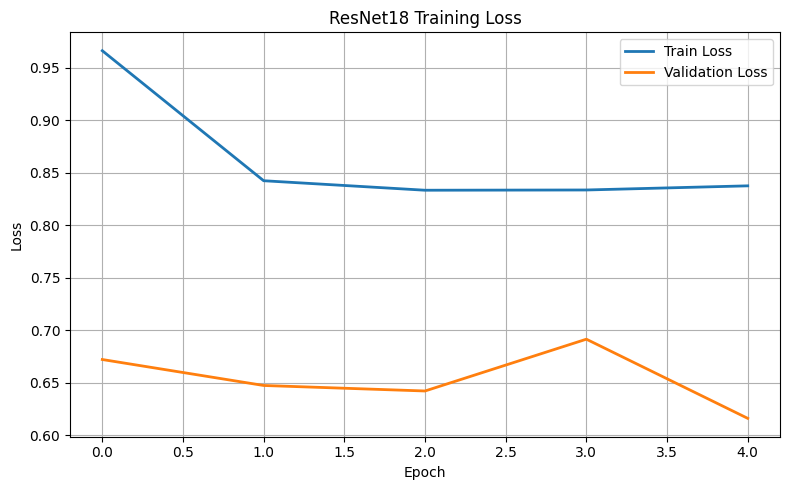

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training Loss")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/resnet18_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

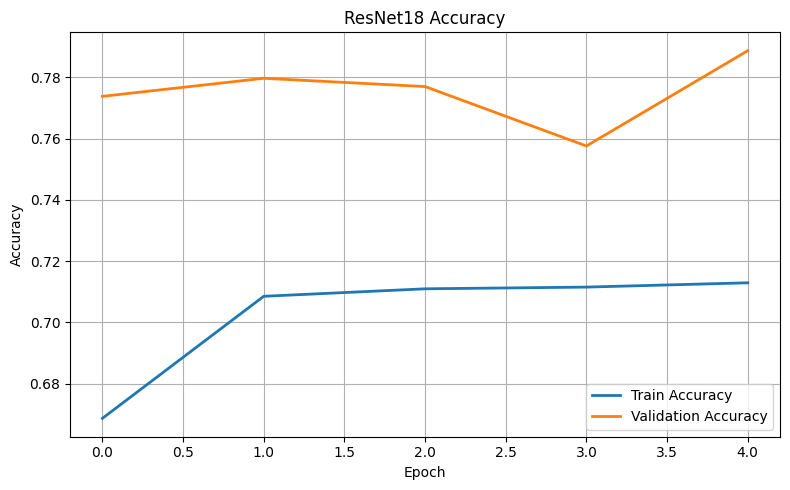

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy", linewidth=2)
plt.plot(history["val_acc"], label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("ResNet18 Accuracy")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/resnet18_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Confusion Matrix

The confusion matrix provides a detailed overview of classification performance for each class.

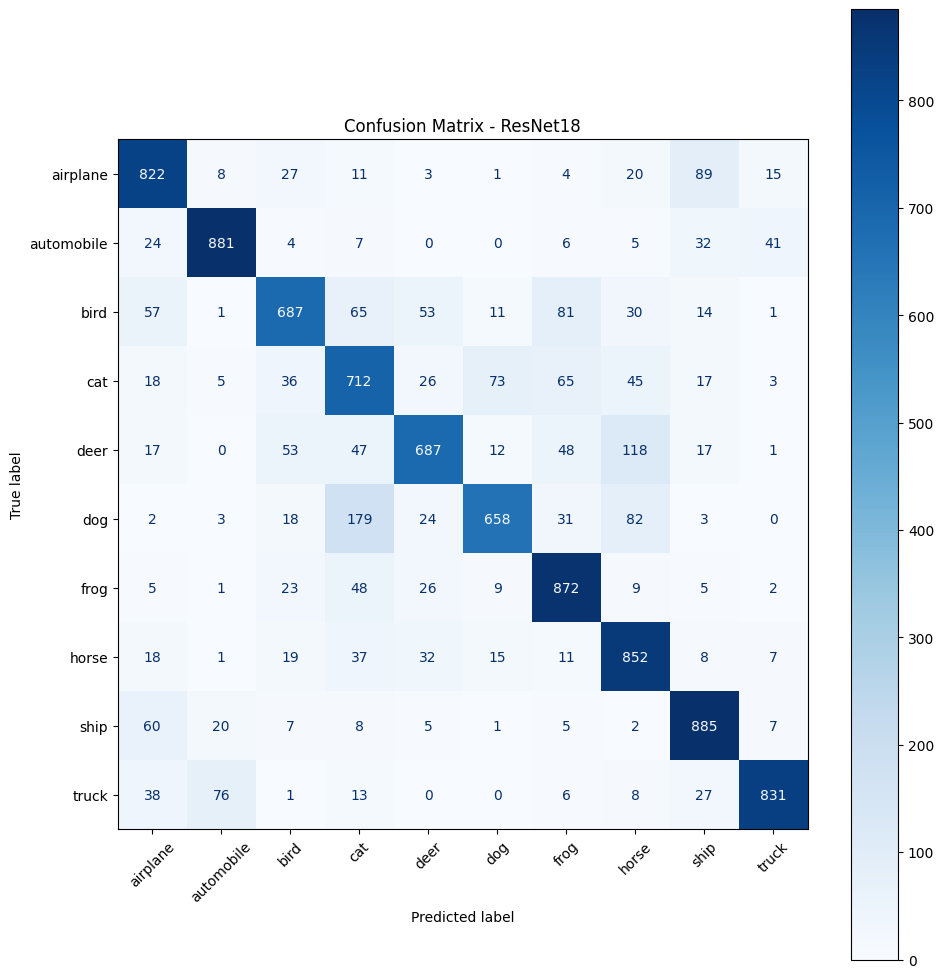

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(targets, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - ResNet18")

plt.tight_layout()

plt.savefig(
    "figures/confusion_matrix_resnet18.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Experiment Summary

The first benchmark experiment has been completed successfully.

Generated artifacts:

- Best model checkpoint
- Performance metrics
- Training curves
- Confusion matrix

These outputs will be used later for benchmark comparison with EfficientNet and Vision Transformer.

In [19]:
print("="*70)
print("ResNet18 Benchmark Completed")
print("="*70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print()

print("Saved Files")

print("- models/best_resnet18.pth")
print("- results/resnet18_metrics.csv")
print("- figures/resnet18_loss.png")
print("- figures/resnet18_accuracy.png")
print("- figures/confusion_matrix_resnet18.png")

print()

print(f"Training Time : {training_time:.2f} sec")

print("="*70)

ResNet18 Benchmark Completed
Accuracy  : 0.7887
Precision : 0.7944
Recall    : 0.7887
F1 Score  : 0.7882

Saved Files
- models/best_resnet18.pth
- results/resnet18_metrics.csv
- figures/resnet18_loss.png
- figures/resnet18_accuracy.png
- figures/confusion_matrix_resnet18.png

Training Time : 435.57 sec
